In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

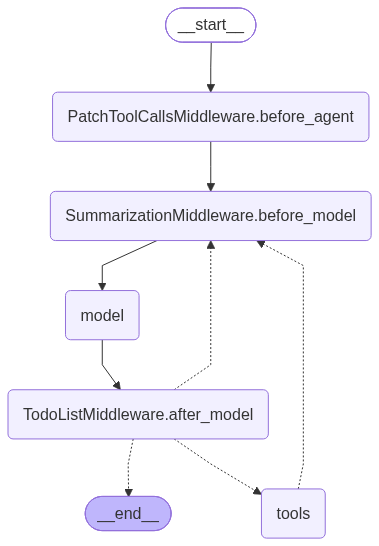

In [4]:
## Context Engineering - Input Context for the Agent - System prompt
from deepagents import create_deep_agent
from langchain.agents.middleware import TodoListMiddleware, SummarizationMiddleware
agent = create_deep_agent(model="openai:gpt-5.4",
system_prompt=(
    "You are a research assistant specializing for the scientific literature. "
    "Always cite sources. Use the subagents for the parallel research on different topics. "
),
middleware=[
        # 1. Summarizes old chat history when token thresholds are reached
        SummarizationMiddleware(
            model="openai:gpt-5.4",
            trigger=("tokens", 2500),  # Compress when total tokens hit 4000
            keep=("messages", 5)      # Always keep the 20 most recent messages intact
        ),
        # 2. Tracks task execution steps
        TodoListMiddleware() 
    ]
)
agent

In [5]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='627de034-3d5a-49c9-9f4b-697582f2b0be'),
  AIMessage(content=[{'arguments': '{"description":"Research the term \'deepagent\' in scientific and technical literature/web context. Determine what it refers to, including whether it is a specific framework/library/product or a general concept. Return a concise summary with sources and publication dates if available.","subagent_type":"general-purpose"}', 'call_id': 'call_v35d8ZwmVKYzEVdM13N7XZdS', 'name': 'task', 'type': 'function_call', 'id': 'fc_0f3c40e6ce0e937e006a73780baef4819d83c7cf0d13ca5fb9', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0f3c40e6ce0e937e006a73780ab148819da11ae1f1dea2425d', 'created_at': 1785952266.0, 'metadata': {}, 'model': 'gpt-5.4-2026-03-05', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05'}, id='

In [8]:
result["messages"][-1].content

[{'type': 'text',
  'text': '“DeepAgent” usually refers to a specific AI agent framework/product, not a standard scientific term.\n\nMost commonly today:\n- **LangChain Deep Agents / `deepagents`**: a framework/library for building autonomous agents with planning, subagents, tools, and workspace/file operations.  \n  Sources: LangChain docs; GitHub repo `langchain-ai/deepagents`.\n- More generally, **“deep agent”** can also mean an agent powered by deep learning, especially in reinforcement learning contexts, but that’s descriptive usage rather than a formal, widely standardized term.\n\nSo the answer depends on context:\n\n1. **If you saw “DeepAgent” capitalized**  \n   It likely means a named software project or product, especially LangChain’s Deep Agents.  \n   Sources:\n   - LangChain documentation: “Deep Agents”  \n   - GitHub: `langchain-ai/deepagents`\n\n2. **If you saw “deep agent” in a paper**  \n   It likely just means an intelligent agent using deep neural networks or deep r

In [10]:
## Context Engineering - Input Context for the Agent - Agents.md file
from pathlib import Path
agents_md_path = Path("projects/Agents.md").read_text(encoding="utf-8")
agents_md_path

'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [13]:
from langgraph.checkpoint.memory import MemorySaver
agent = create_deep_agent(
    model="openai:gpt-5.4",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md_path}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)


[{'type': 'text', 'text': 'I’m a deep agent for this project context.\n\nI should follow the guidance in `Agents.md` as my source of truth, especially these rules:\n\n- Plan first for multi-step tasks.\n- Offload bulky intermediate work to files.\n- Delegate self-contained subtasks to subagents when useful.\n- Use the project’s architecture and conventions described there rather than assumptions.\n- Give concise final answers, with sources when research is involved.\n\nIn short: I’m an agent built for complex, multi-step work using planning, file-based context offloading, and subagents, and I should operate according to this project guide.', 'annotations': [], 'id': 'msg_02fd5705a515b3a7006a73806ee58081a0932f86dc9a9892f8', 'phase': 'final_answer'}]


In [16]:
from deepagents.backends.utils import create_file_data
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md_path)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I don’t have persistent personal memory across conversations.\n\nIn this chat, I know:\n- the instructions you provided here\n- the `Agents.md` project guide you pasted\n- that I’m expected to answer in line with that guide\n\nSo, “my memory” right now is just this conversation context, not a lasting private store.\n\nWho I am in this context:\n- an AI assistant accessed via API\n- operating as a “deep agent” according to your `Agents.md`\n- meant to use planning, file/context offloading, and subagents for complex tasks\n- expected to treat `Agents.md` as the authoritative guide for how I should operate\n\nConcise version:\n- Memory: only this chat’s context\n- Identity here: a deep agent following your project guide', 'annotations': [], 'id': 'msg_02fd5705a515b3a7006a7382c378dc81a0a5206255ec464f43', 'phase': 'final_answer'}]


In [17]:
## from StoreBackend, we can also retrieve the file content from the agent's memory
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md_path))

store_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I don’t have any meaningful saved memory loaded right now.\n\nWhat I can see in memory is literally:\n\n- “No memory loaded”\n\nWho I am:\n\n- I’m an AI assistant running via an API in this environment.\n- I can answer questions, help write/debug code, inspect files, and modify files if you ask.\n- In this workspace, I can also save useful long-term notes about your preferences or workflow when that would help future turns.\n\nIf you want, I can also explain:\n- what I remember across chats here,\n- what I can and can’t store,\n- or help set a short memory profile for you.', 'annotations': [], 'id': 'msg_0205d41ee775eaf3006a7383f0ae208191abea1098c607d5f8', 'phase': 'final_answer'}]


In [18]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='27886511-3011-47f8-b4c7-d0e2c6c449a5'),
  AIMessage(content=[{'type': 'text', 'text': 'I don’t have any meaningful saved memory loaded right now.\n\nWhat I can see in memory is literally:\n\n- “No memory loaded”\n\nWho I am:\n\n- I’m an AI assistant running via an API in this environment.\n- I can answer questions, help write/debug code, inspect files, and modify files if you ask.\n- In this workspace, I can also save useful long-term notes about your preferences or workflow when that would help future turns.\n\nIf you want, I can also explain:\n- what I remember across chats here,\n- what I can and can’t store,\n- or help set a short memory profile for you.', 'annotations': [], 'id': 'msg_0205d41ee775eaf3006a7383f0ae208191abea1098c607d5f8', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_0205d41ee775eaf3006a7383efeca48191aea643131d7f

In [19]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I have a small project memory loaded from a file called `AGENTS.md`.\n\nIn it, I’m described as a **deep agent** for complex, multi-step tasks. The memory says my main patterns are:\n\n- **Plan first** for bigger tasks\n- **Use files** to offload large intermediate work\n- **Delegate to subagents** for independent research/tasks\n- Treat `AGENTS.md` as reference about the project architecture\n- Give concise final answers, with sources when research is involved\n\nIt also includes a high-level description of the deep-agent architecture:\n\n- built on **LangGraph**\n- supports:\n  - planning/todos\n  - filesystem tools\n  - subagents\n  - custom tools\n\nWho am I? In this chat, I’m your AI assistant accessed through an API. More specifically, I’m operating with that “deep agent” project context, so I’m meant to help with longer, structured tasks as well as normal Q&A.\n\nIf you want, I can also:\n- quote the memory more literally,\n- summarize only the durable

In [20]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'LLM Gateways are systems that sit between an application and one or more large language model providers.\n\nThey typically provide a unified layer for things like:\n\n- **Routing:** choose which model/provider handles a request\n- **Fallbacks:** switch providers if one fails\n- **Authentication:** centralize API key handling\n- **Observability:** log prompts, latency, cost, errors\n- **Rate limiting and quotas**\n- **Caching**\n- **Policy enforcement / guardrails**\n- **Cost control**\n- **Load balancing**\n- **Standardized API format**\n\nIn practice, an LLM gateway can let your app talk to “one endpoint” while the gateway decides whether to use OpenAI, Anthropic, Google, a local model, etc.\n\nExamples of products/patterns often called LLM gateways include:\n- AI proxy layers\n- model routers\n- inference gateways\n- unified LLM APIs\n\nA simple mental model:\n- **Without gateway:** your app integrates separately with each model provider\n- **With gateway:*

Skills - Context Engineering

In [21]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}

In [23]:
## read skills from each type
skills_dir = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8"))
    for name in skills_dir
}

In [24]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [25]:
agent=create_deep_agent(
    model="openai:gpt-5.4",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Available skills:\n\n- aws\n  - Use for AWS services, architecture, boto3/AWS CLI, cost optimization, and cloud security best practices.\n  - Examples: EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker.\n\n- langgraph\n  - Use for LangGraph and stateful agent workflow design.\n  - Examples: StateGraph, nodes/edges, routing, checkpointers, persistence, memory, HITL, subgraphs, streaming.\n\n- python\n  - Use for Python coding help.\n  - Examples: writing, debugging, refactoring, explaining, reviewing code, async, decorators, typing, packaging, testing.\n\n- report-writer\n  - Use after substantive answers to create a structured markdown report saved to a file.\n  - Especially useful when you ask for a report, summary document, or saved output.\n\nHow I decide:\n- I match your request to the skill domain.\n- If relevant, I read that skill’s `/skills/.../SKILL.md` instructions.\n- Then I follow its workflow and use any supporting file

In [26]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/langgraph/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_xgsei0RmdAdpk9K5FHn4qQxG', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0d8f59671e39274a006a74b80a1b78819f861679a3b6af215b', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_a408NkHYx139uRGN4BoTTZ9C', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0d8f59671e39274a006a74b80a1b8c819fba1db54961af38f5', 'status': 'completed'}]
Tool Calls:
  read_file (call_xgsei0RmdAdpk9K5FHn4qQxG)
 Call ID: call_xgsei0RmdAdpk9K5FHn4qQxG
  Args:
    file_path: /skills/langgraph/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_a408NkHYx139uRGN4BoTT

In [ ]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

In [ ]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()